# Chapter 15 — The Black-Scholes-Merton Model
## *Options, Futures, and Other Derivatives* (11th ed.) — John C. Hull

---

### 学習目標

この Notebook では、Chapter 15 で扱われる以下のトピックを、**理論 → 実装 → 可視化 → 解釈** の順に学びます。

* 株価の幾何ブラウン運動 (GBM) と対数正規性
* ボラティリティの定義・推定・年率化
* デルタヘッジの直感と Black-Scholes-Merton PDE
* リスク中立評価の考え方
* BSM 公式の実装と put-call parity
* 累積標準正規分布 $N(x)$ の役割
* ワラントと従業員ストックオプション
* インプライド・ボラティリティの逆算
* 配当利回りを含む BSM 拡張
* モンテカルロによる付録 15A の数値確認

### Chapter 15 の位置づけ

Chapter 15 は、オプション価格理論の中核をなす章です。
前章 (Ch.13–14) で学んだ二項モデル・Wiener 過程を**連続時間**に拡張し、
BSM 公式という closed-form solution を導きます。
後続の Ch.19 (Greeks), Ch.20 (Volatility Smile), Ch.21 (数値手法) はすべてこの章の上に構築されます。

> **この Notebook では、理論 → 実装 → 可視化 → 解釈 の順に進みます。**

> **核心** — BSM は『連続時間の複製』。デルタヘッジを連続で行えば、オプションは無リスクに複製できる。<br>
> **直感** — GBM＋伊藤の補題からポートフォリオの確率項が消え、価格は PDE（＝割引期待値）で決まる。<br>
> **実務** — 全オプション市場の共通言語。建値・IV・グリークスはすべて BSM を基準に回る。

> **実務での出番 — なぜ BSM 価格に期待リターン μ が現れないか**
>
> 直感に反するが、オプション価格は原資産の期待リターン μ に依存しない。理由は複製：デルタヘッジしたポートフォリオは瞬間的に無リスクになり、無リスク金利でしか増えない。だから μ（強気か弱気か）は相殺されて消える。価格を決めるのは σ・r・S・T だけ——『方向は当てなくてよい、ボラだけ当てればよい』というデリバティブ取引の核心がここにある。

---
## 1. ライブラリ読み込みと表示設定

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib          # 日本語フォントを自動設定
from scipy.stats import norm
from scipy.optimize import brentq

# ---------- 表示設定 ----------
plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})
pd.set_option("display.float_format", "{:.6f}".format)

# ---------- 乱数シード ----------
SEED = 42
rng = np.random.default_rng(SEED)

print("Setup complete.")

Setup complete.


---
## 2. 共通関数セル

以降のセクションで繰り返し使う関数をここにまとめて定義します。
すべての関数に docstring を付けています。

In [2]:
# ===== 2-1. GBM シミュレーション =====

def simulate_gbm_paths(S0, mu, sigma, T, n_steps, n_paths, rng):
    """幾何ブラウン運動のサンプルパスを生成する。

    Parameters
    ----------
    S0 : float  -- 初期価格
    mu : float  -- ドリフト (年率)
    sigma : float  -- ボラティリティ (年率; >= 0)
    T : float  -- 期間 (年; > 0)
    n_steps : int  -- 時間ステップ数
    n_paths : int  -- パス数
    rng : np.random.Generator

    Returns
    -------
    t : ndarray, shape (n_steps+1,)
    S : ndarray, shape (n_paths, n_steps+1)
    """
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    Z = rng.standard_normal((n_paths, n_steps))
    log_increments = (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_S = np.zeros((n_paths, n_steps + 1))
    log_S[:, 0] = np.log(S0)
    log_S[:, 1:] = np.log(S0) + np.cumsum(log_increments, axis=1)
    S = np.exp(log_S)
    return t, S


# ===== 2-2. 対数収益率 =====

def compute_log_returns(prices):
    """価格系列から対数収益率を計算する。"""
    prices = np.asarray(prices, dtype=float)
    return np.diff(np.log(prices))


# ===== 2-3. 年率化ボラティリティ =====

def annualized_volatility(log_returns, periods_per_year=252):
    """対数収益率の標準偏差を年率化する。"""
    return np.std(log_returns, ddof=1) * np.sqrt(periods_per_year)


# ===== 2-4. 入力バリデーションヘルパー  [updated] =====

def _validate_bsm_inputs(S, K, T, sigma):
    """BSM 関数の入力を検証する。不正値のとき ValueError を送出する。"""
    S_arr = np.asarray(S, dtype=float)
    if np.any(S_arr <= 0):
        raise ValueError(f"S は正の値でなければなりません (受け取った値: {S_arr})")
    if K <= 0:
        raise ValueError(f"K は正の値でなければなりません (受け取った値: {K})")
    if T < 0:
        raise ValueError(f"T は 0 以上でなければなりません (受け取った値: {T})")
    if sigma < 0:
        raise ValueError(f"sigma は 0 以上でなければなりません (受け取った値: {sigma})")


# ===== 2-5. BSM d1, d2  [updated: edge case handling] =====

def bsm_d1_d2(S, K, T, r, sigma):
    """BSM 公式の d1, d2 を計算する。

    Parameters
    ----------
    S : float または array  -- 現在の株価 (> 0)
    K : float  -- 行使価格 (> 0)
    T : float  -- 満期までの時間 (年; >= 0)
    r : float  -- 無リスク金利 (連続複利)
    sigma : float  -- ボラティリティ (年率; >= 0)

    Returns
    -------
    d1, d2 : float または ndarray
        T == 0 または sigma == 0 の場合は (nan, nan) を返す。
        呼び出し側の価格/デルタ関数がエッジケース処理を行う。

    Raises
    ------
    ValueError : S <= 0, K <= 0, T < 0, sigma < 0 のとき
    """
    _validate_bsm_inputs(S, K, T, sigma)
    S_arr = np.asarray(S, dtype=float)
    denom = float(sigma) * np.sqrt(float(T))  # sigma, T ともにスカラーを前提
    if denom == 0.0:
        # T==0 または sigma==0 → 標準式は適用不可; nan を返し呼び出し側で処理
        nan_val = np.full_like(S_arr, np.nan) if S_arr.ndim > 0 else np.nan
        return nan_val, nan_val
    d1 = (np.log(S_arr / K) + (r + 0.5 * sigma**2) * T) / denom
    d2 = d1 - denom
    return d1, d2


# ===== 2-6. BSM Call / Put  [updated: edge cases] =====

def bsm_call_price(S, K, T, r, sigma):
    """European call の BSM 価格。

    Edge cases
    ----------
    T == 0     : max(S - K, 0)            （満期ペイオフ）
    sigma == 0 : max(S - K*exp(-r*T), 0)  （確定的 forward の割引現在価値）
    """
    _validate_bsm_inputs(S, K, T, sigma)
    S = np.asarray(S, dtype=float)
    if T == 0.0:
        return np.maximum(S - K, 0.0)          # updated: 満期ペイオフ
    if sigma == 0.0:
        return np.maximum(S - K * np.exp(-r * T), 0.0)  # updated: vol=0
    d1, d2 = bsm_d1_d2(S, K, T, r, sigma)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bsm_put_price(S, K, T, r, sigma):
    """European put の BSM 価格。

    Edge cases
    ----------
    T == 0     : max(K - S, 0)
    sigma == 0 : max(K*exp(-r*T) - S, 0)
    """
    _validate_bsm_inputs(S, K, T, sigma)
    S = np.asarray(S, dtype=float)
    if T == 0.0:
        return np.maximum(K - S, 0.0)          # updated
    if sigma == 0.0:
        return np.maximum(K * np.exp(-r * T) - S, 0.0)  # updated
    d1, d2 = bsm_d1_d2(S, K, T, r, sigma)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)


# ===== 2-7. BSM Delta  [updated: edge cases] =====

def bsm_call_delta(S, K, T, r, sigma):
    """European call の delta（dC/dS）。

    Edge cases
    ----------
    T == 0     : S > K → 1, S < K → 0, S == K → 0.5（不連続点の中点規則）
    sigma == 0 : S > K*exp(-rT) → 1, それ以外 → 0（確定的 forward に対応）
    """
    _validate_bsm_inputs(S, K, T, sigma)
    S = np.asarray(S, dtype=float)
    if T == 0.0:
        # updated: 満期での delta は不連続; 慣例として中点を 0.5 とする
        return np.where(S > K, 1.0, np.where(S < K, 0.0, 0.5))
    if sigma == 0.0:
        forward_pv = K * np.exp(-r * T)
        return np.where(S > forward_pv, 1.0, 0.0)  # updated
    d1, _ = bsm_d1_d2(S, K, T, r, sigma)
    return norm.cdf(d1)


def bsm_put_delta(S, K, T, r, sigma):
    """European put の delta（dP/dS）。

    Edge cases
    ----------
    T == 0     : S > K → 0, S < K → -1, S == K → -0.5
    sigma == 0 : S > K*exp(-rT) → 0, それ以外 → -1
    """
    _validate_bsm_inputs(S, K, T, sigma)
    S = np.asarray(S, dtype=float)
    if T == 0.0:
        return np.where(S > K, 0.0, np.where(S < K, -1.0, -0.5))  # updated
    if sigma == 0.0:
        forward_pv = K * np.exp(-r * T)
        return np.where(S > forward_pv, 0.0, -1.0)  # updated
    d1, _ = bsm_d1_d2(S, K, T, r, sigma)
    return norm.cdf(d1) - 1.0


# ===== 2-8. Put-Call Parity =====

def put_call_parity_gap(S, K, T, r, call_price, put_price):
    """Put-call parity の残差を返す。C - P - (S - K*exp(-rT)) = 0 が成立するなら 0。"""
    return call_price - put_price - (S - K * np.exp(-r * T))


# ===== 2-9. BSM Vega  [updated: edge cases] =====

def bsm_vega(S, K, T, r, sigma):
    """BSM Vega（call/put 共通）。T==0 または sigma==0 のとき 0 を返す。"""
    _validate_bsm_inputs(S, K, T, sigma)
    if T == 0.0 or sigma == 0.0:
        return 0.0  # updated: edge case
    d1, _ = bsm_d1_d2(S, K, T, r, sigma)
    return float(S) * norm.pdf(d1) * np.sqrt(T)


# ===== 2-10. Implied Volatility (Bisection)  [updated] =====

def implied_vol_bisection(market_price, S, K, T, r, option_type="call",
                          tol=1e-8, max_iter=200):
    """二分法で implied volatility を求める。

    Parameters
    ----------
    market_price : float  -- 市場で観測されたオプション価格
    S, K, T, r   : float  -- BSM パラメータ
    option_type  : str    -- 'call' or 'put'
    tol          : float  -- 許容誤差（価格差の絶対値）
    max_iter     : int    -- 最大反復数

    Returns
    -------
    dict with keys
        iv         : float  -- 解のボラティリティ（不収束時は最終推定値または nan）
        history    : list   -- 各反復での sigma の推移
        converged  : bool
        iterations : int
        message    : str
    """
    price_func = bsm_call_price if option_type == "call" else bsm_put_price
    disc = np.exp(-r * T)

    # updated: no-arbitrage bounds チェック
    if option_type == "call":
        lb = max(S - K * disc, 0.0)   # lower bound: intrinsic (discounted forward)
        ub = S                          # upper bound: call cannot exceed spot
    else:
        lb = max(K * disc - S, 0.0)    # lower bound: put intrinsic
        ub = K * disc                   # upper bound: put cannot exceed PV(K)

    if market_price < lb - tol:
        msg = (f"市場価格 {market_price:.4f} が no-arbitrage 下限 {lb:.4f} を"
               f"下回っています。IV を計算できません。")
        return {"iv": np.nan, "history": [], "converged": False,
                "iterations": 0, "message": msg}
    if market_price > ub + tol:
        msg = (f"市場価格 {market_price:.4f} が no-arbitrage 上限 {ub:.4f} を"
               f"上回っています。IV を計算できません。")
        return {"iv": np.nan, "history": [], "converged": False,
                "iterations": 0, "message": msg}

    lo, hi = 1e-6, 5.0
    history = []
    mid = 0.5 * (lo + hi)
    for i in range(max_iter):
        mid = 0.5 * (lo + hi)
        history.append(mid)
        diff = price_func(S, K, T, r, mid) - market_price
        if abs(diff) < tol:
            return {"iv": mid, "history": history, "converged": True,
                    "iterations": i + 1, "message": "収束しました"}
        if diff > 0:
            hi = mid
        else:
            lo = mid

    return {"iv": mid, "history": history, "converged": False,
            "iterations": max_iter,
            "message": f"最大反復数 {max_iter} に達しました（不収束）"}


# ===== 2-11. Implied Volatility (Newton)  [updated] =====

def implied_vol_newton(market_price, S, K, T, r, option_type="call",
                       sigma0=0.3, tol=1e-8, max_iter=100):
    """Newton-Raphson 法で implied volatility を求める。

    Parameters
    ----------
    market_price : float
    S, K, T, r   : float
    option_type  : str    -- 'call' or 'put'
    sigma0       : float  -- 初期推定値（デフォルト 0.3）
    tol          : float  -- 許容誤差
    max_iter     : int    -- 最大反復数

    Returns
    -------
    dict with keys: iv, history, converged, iterations, message
    """
    price_func = bsm_call_price if option_type == "call" else bsm_put_price
    sigma = sigma0
    history = [sigma]
    VEGA_MIN = 1e-8   # updated: vega が極端に小さいときは更新を停止
    SIGMA_MAX = 10.0  # updated: 発散ガード（sigma > 1000% は非現実的）

    for i in range(max_iter):
        price_est = price_func(S, K, T, r, sigma)
        diff = price_est - market_price
        if abs(diff) < tol:
            return {"iv": sigma, "history": history, "converged": True,
                    "iterations": i + 1, "message": "収束しました"}
        vega = bsm_vega(S, K, T, r, sigma)
        if vega < VEGA_MIN:
            # updated: vega 極小 → Newton step 不安定; 反復を停止
            return {"iv": sigma, "history": history, "converged": False,
                    "iterations": i + 1,
                    "message": f"Vega が {vega:.2e} と極小のため更新を停止しました"}
        sigma_new = sigma - diff / vega
        sigma_new = float(np.clip(sigma_new, 1e-6, SIGMA_MAX))  # updated: 発散・負値ガード
        history.append(sigma_new)
        sigma = sigma_new

    return {"iv": sigma, "history": history, "converged": False,
            "iterations": max_iter,
            "message": f"最大反復数 {max_iter} に達しました（不収束）"}


def implied_vol(market_price, S, K, T, r, option_type="call",
                sigma0=0.3, tol=1e-8, max_iter=100):
    """Newton-Raphson を試み、失敗した場合は Bisection にフォールバックするラッパー。  [updated]

    Parameters / Returns は implied_vol_newton と同じ。
    """
    result = implied_vol_newton(market_price, S, K, T, r, option_type,
                                sigma0=sigma0, tol=tol, max_iter=max_iter)
    if result["converged"]:
        return result
    # updated: Newton 失敗 → Bisection にフォールバック
    bi_result = implied_vol_bisection(market_price, S, K, T, r, option_type,
                                      tol=tol, max_iter=200)
    bi_result["message"] = ("Newton 法が収束せず Bisection にフォールバック: "
                             + bi_result["message"])
    return bi_result


# ===== 2-12. BSM with dividend yield =====

def bsm_call_with_dividend_yield(S, K, T, r, sigma, q):
    """配当利回り q を考慮した European call の BSM 価格。T==0 のとき満期ペイオフを返す。"""
    S = np.asarray(S, dtype=float)
    if T == 0.0:
        return np.maximum(S - K, 0.0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def bsm_put_with_dividend_yield(S, K, T, r, sigma, q):
    """配当利回り q を考慮した European put の BSM 価格。T==0 のとき満期ペイオフを返す。"""
    S = np.asarray(S, dtype=float)
    if T == 0.0:
        return np.maximum(K - S, 0.0)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)


print("共通関数の定義が完了しました。")


共通関数の定義が完了しました。


---
## 3. §15.1–15.3 株価過程と対数正規性

### 理論

株価 $S$ は**幾何ブラウン運動 (Geometric Brownian Motion, GBM)** に従うと仮定します:

$$
dS = \mu\, S\, dt + \sigma\, S\, dz
$$

ここで $\mu$ は期待収益率（年率）、$\sigma$ はボラティリティ（年率）、$dz$ は Wiener 過程の増分です。

伊藤の補題を $\ln S$ に適用すると、

$$
d(\ln S) = \left(\mu - \tfrac{\sigma^2}{2}\right) dt + \sigma\, dz
$$

よって $\ln S_T - \ln S_0$ は**正規分布**に従い、$S_T$ は**対数正規分布**に従います:

$$
\ln S_T \sim \mathcal{N}\!\left(\ln S_0 + \left(\mu - \tfrac{\sigma^2}{2}\right)T,\;\sigma^2 T\right)
$$

### なぜ対数を見るのか

* 株価 $S$ は非負であるため直接正規分布を仮定できない。
* $\ln S$ は実数全体を取れるため正規分布を仮定できる。
* 対数収益率 $\ln(S_T / S_0)$ は加法的で扱いやすい。
* **Arithmetic return** $\frac{S_T - S_0}{S_0}$ と **Log return** $\ln \frac{S_T}{S_0}$ は、小さな値ではほぼ一致するが、長期・大変動では乖離する。

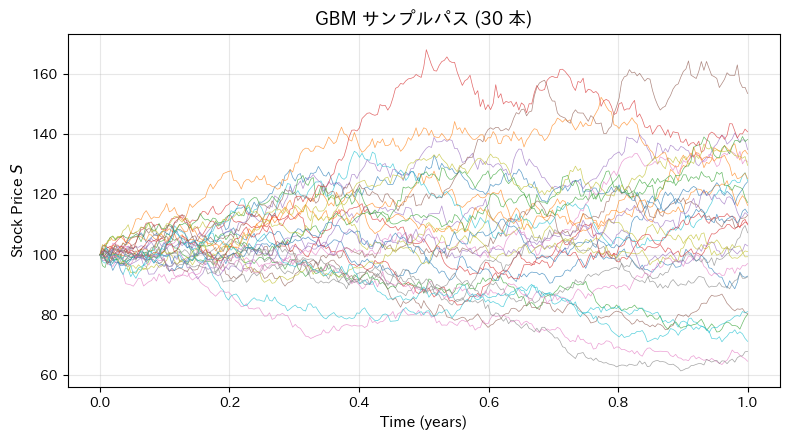

In [3]:
# --- 3-1. GBM パスのシミュレーション ---
S0 = 100.0
mu = 0.10
sigma = 0.20
T = 1.0
n_steps = 252
n_paths = 10000

t, S = simulate_gbm_paths(S0, mu, sigma, T, n_steps, n_paths, rng)

# パス可視化 (先頭 30 本)
fig, ax = plt.subplots()
for i in range(30):
    ax.plot(t, S[i], linewidth=0.5, alpha=0.7)
ax.set_title("GBM サンプルパス (30 本)")
ax.set_xlabel("Time (years)")
ax.set_ylabel("Stock Price $S$")
plt.tight_layout()
plt.show()

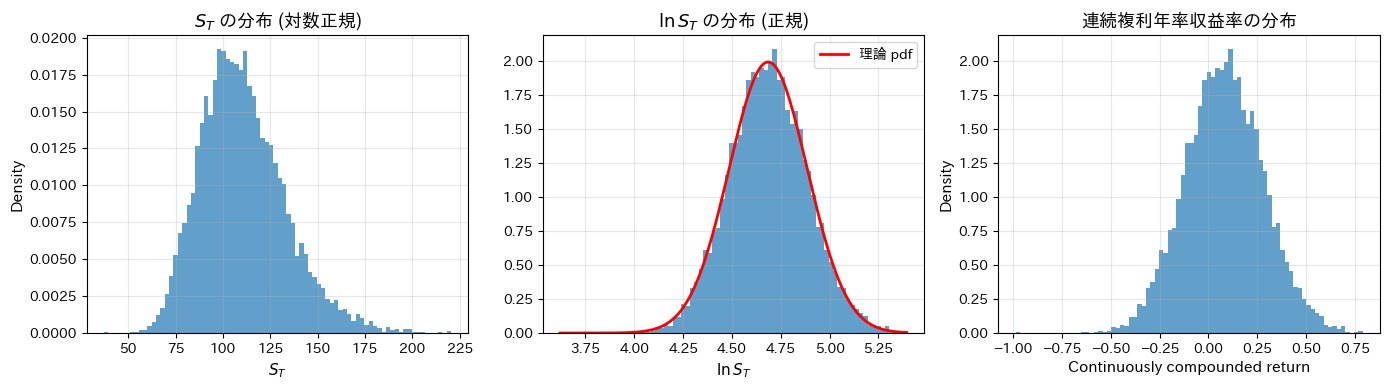

S_T  mean=110.72  std=22.44
ln(S_T)  mean=4.6869  theory=4.6852
ln(S_T)  std =0.1999  theory=0.2000


In [4]:
# --- 3-2. S_T の分布 ---
ST = S[:, -1]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) S_T のヒストグラム
axes[0].hist(ST, bins=80, density=True, alpha=0.7)
axes[0].set_title(r"$S_T$ の分布 (対数正規)")
axes[0].set_xlabel(r"$S_T$")
axes[0].set_ylabel("Density")

# (b) log(S_T) のヒストグラム
logST = np.log(ST)
mu_log = np.log(S0) + (mu - 0.5 * sigma**2) * T
sigma_log = sigma * np.sqrt(T)
x = np.linspace(logST.min(), logST.max(), 200)
axes[1].hist(logST, bins=80, density=True, alpha=0.7)
axes[1].plot(x, norm.pdf(x, mu_log, sigma_log), "r-", linewidth=2, label="理論 pdf")
axes[1].set_title(r"$\ln S_T$ の分布 (正規)")
axes[1].set_xlabel(r"$\ln S_T$")
axes[1].legend()

# (c) 連続複利収益率
cc_return = np.log(ST / S0) / T
axes[2].hist(cc_return, bins=80, density=True, alpha=0.7)
axes[2].set_title("連続複利年率収益率の分布")
axes[2].set_xlabel("Continuously compounded return")
axes[2].set_ylabel("Density")

plt.tight_layout()
plt.show()

print(f"S_T  mean={ST.mean():.2f}  std={ST.std():.2f}")
print(f"ln(S_T)  mean={logST.mean():.4f}  theory={mu_log:.4f}")
print(f"ln(S_T)  std ={logST.std():.4f}  theory={sigma_log:.4f}")

### 確認ポイント (Section 3)

1. $\ln S_T$ のヒストグラムが正規分布の pdf とよく重なることを確認しましたか？
2. `S_T.mean()` は $S_0 e^{\mu T}$ に近いですか？理論値を計算して比較してみましょう。
3. $\mu - \sigma^2/2$ の項がなぜ現れるか、伊藤の補題で説明できますか？

---
## 4. §15.4 ボラティリティ

### 理論

ボラティリティ $\sigma$ は**対数収益率の年率標準偏差**として定義されます。

$$
u_i = \ln \frac{S_i}{S_{i-1}}
$$

日次観測ならば

$$
\hat{\sigma}_{\text{daily}} = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(u_i - \bar{u})^2}, \qquad
\hat{\sigma}_{\text{annual}} = \hat{\sigma}_{\text{daily}} \times \sqrt{252}
$$

### 実現ボラとモデル上の $\sigma$ の関係

* BSM モデルでは $\sigma$ は定数と仮定しますが、実際の市場では時間とともに変動します。
* **ローリング・ボラティリティ**（窓長 $w$ 日の区間で推定）を使うと、ボラティリティの時間変化を可視化できます。
* 窓長が短いほどノイジー、長いほど滑らかだが反応が遅い。

In [5]:
# --- 4-1. サンプル価格系列の作成 ---
n_days = 504  # 2年分
t_vol, S_vol = simulate_gbm_paths(S0, mu=0.08, sigma=0.25, T=2.0,
                                   n_steps=n_days, n_paths=1, rng=rng)
prices = S_vol[0]

# 対数収益率
log_ret = compute_log_returns(prices)

# 年率ボラ
ann_vol = annualized_volatility(log_ret)
print(f"全期間の年率ボラティリティ: {ann_vol:.4f}  (真の値: 0.2500)")

全期間の年率ボラティリティ: 0.2502  (真の値: 0.2500)


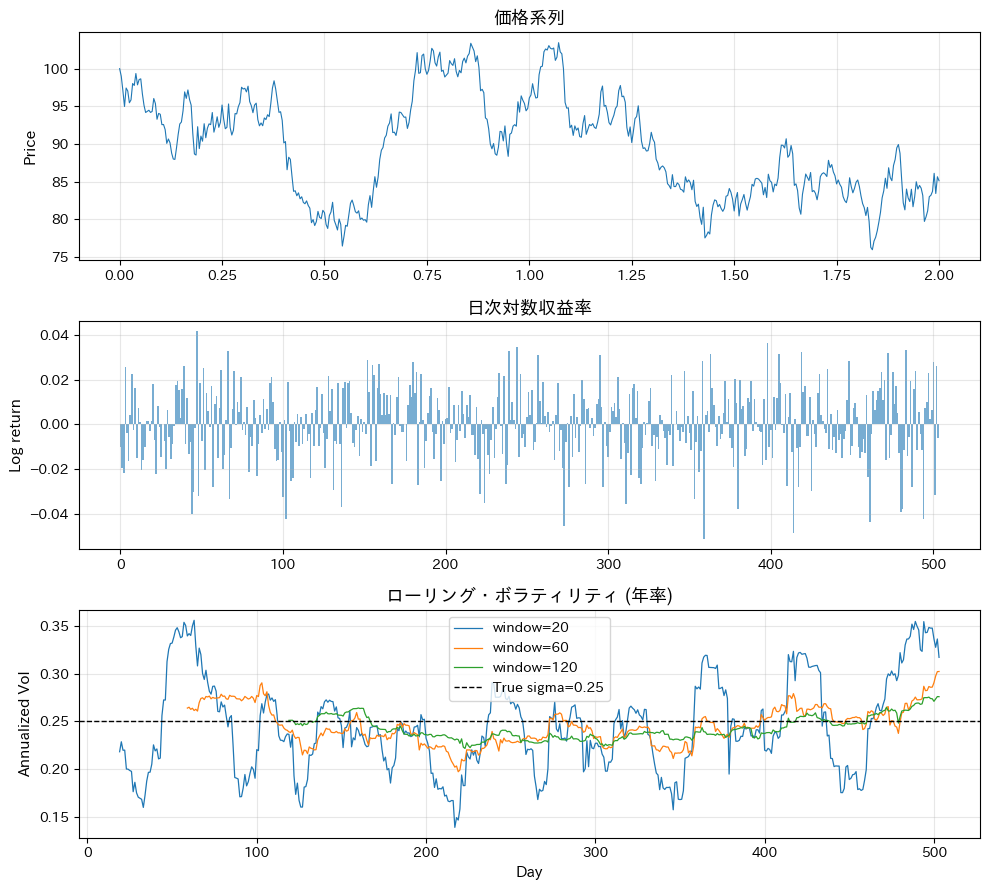

In [6]:
# --- 4-2. 可視化 ---
fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=False)

# (a) 価格系列
axes[0].plot(t_vol, prices, linewidth=0.8)
axes[0].set_title("価格系列")
axes[0].set_ylabel("Price")

# (b) 対数収益率
axes[1].bar(np.arange(len(log_ret)), log_ret, width=1.0, alpha=0.6)
axes[1].set_title("日次対数収益率")
axes[1].set_ylabel("Log return")

# (c) ローリングボラティリティ
for w in [20, 60, 120]:
    series = pd.Series(log_ret)
    rolling_vol = series.rolling(window=w).std() * np.sqrt(252)
    axes[2].plot(rolling_vol.values, label=f"window={w}", linewidth=0.9)
axes[2].axhline(0.25, color="black", linestyle="--", linewidth=1, label="True sigma=0.25")
axes[2].set_title("ローリング・ボラティリティ (年率)")
axes[2].set_ylabel("Annualized Vol")
axes[2].set_xlabel("Day")
axes[2].legend()

plt.tight_layout()
plt.show()

### 確認ポイント (Section 4)

1. 窓長を変えるとローリング・ボラティリティの推定値がどう変わるか確認しましたか？
2. 全期間の推定値は真の $\sigma=0.25$ にどれくらい近いですか？
3. 短い窓長でのローリング推定値のブレを見て、**モデルの仮定（$\sigma$ 一定）と現実の乖離**を考えてみましょう。

---
## 5. §15.5–15.6 デルタヘッジの直感と BSM PDE

### 理論

#### デルタヘッジの考え方

コール・オプションを 1 単位 short した場合、株価が上がるとオプションの価値が上がり損失が発生します。
この損失を打ち消すために、$\Delta = \partial C / \partial S$ 単位の株を long することで**局所的**にヘッジします。

ポートフォリオ:  $\Pi = -C + \Delta \cdot S$

$S$ の小さな変化 $\delta S$ に対して

$$
\delta\Pi \approx -\frac{\partial C}{\partial S}\,\delta S + \Delta\,\delta S = 0 \quad (\text{if } \Delta = \partial C/\partial S)
$$

#### BSM PDE

デルタヘッジしたポートフォリオは無リスクなので、

$$
\frac{\partial C}{\partial t} + r\,S\,\frac{\partial C}{\partial S} + \tfrac{1}{2}\sigma^2 S^2 \frac{\partial^2 C}{\partial S^2} = r\,C
$$

* **$\mu$ が消える**: ヘッジにより確率的なリターン成分が打ち消されるため。
* これは局所的(infinitesimal)ヘッジであり、離散リバランスでは誤差が残ります。

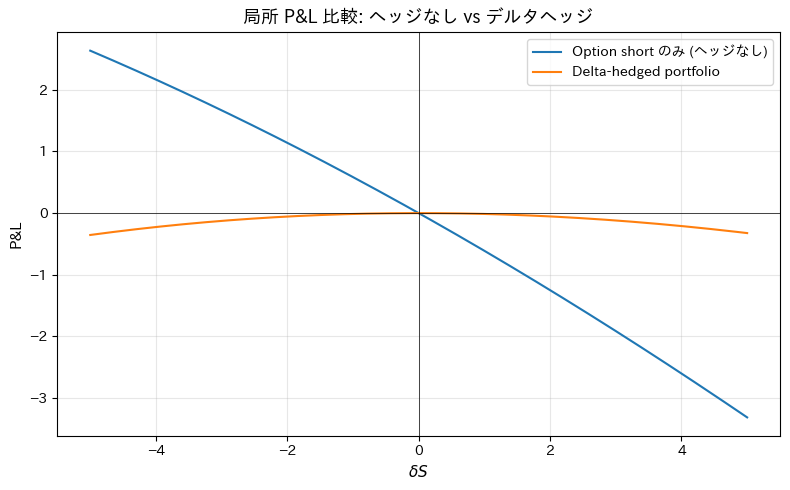

C = 6.8887,  Delta = 0.5977
-> dS=0 付近で hedged P&L ≈ 0 であることを確認


In [7]:
# --- 5-1. デルタヘッジの数値デモ ---

# パラメータ
S_now = 100.0
K_h = 100.0
T_h = 0.5
r_h = 0.05
sigma_h = 0.20

# 現在のオプション価格とデルタ
C_now = bsm_call_price(S_now, K_h, T_h, r_h, sigma_h)
delta_now = bsm_call_delta(S_now, K_h, T_h, r_h, sigma_h)

# 株価の小さな変動
dS_range = np.linspace(-5, 5, 200)
S_new = S_now + dS_range

# 新しいオプション価格 (厳密値)
C_new = bsm_call_price(S_new, K_h, T_h, r_h, sigma_h)

# P&L
pnl_unhedged = -(C_new - C_now)  # option short の P&L
pnl_stock = delta_now * dS_range  # 株 long の P&L
pnl_hedged = pnl_unhedged + pnl_stock  # ヘッジ後の P&L

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(dS_range, pnl_unhedged, label="Option short のみ (ヘッジなし)")
ax.plot(dS_range, pnl_hedged, label="Delta-hedged portfolio")
ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_title("局所 P&L 比較: ヘッジなし vs デルタヘッジ")
ax.set_xlabel(r"$\delta S$")
ax.set_ylabel("P&L")
ax.legend()
plt.tight_layout()
plt.show()

print(f"C = {C_now:.4f},  Delta = {delta_now:.4f}")
print("-> dS=0 付近で hedged P&L ≈ 0 であることを確認")

> **注意: このデモが示していること・示していないこと**
>
> ここで可視化しているのは**現時点での局所的な価格変化に対する one-shot ヘッジ**です。
> 以下の要素は意図的に簡略化しています：
>
> | 簡略化している項目 | 実際の影響 |
> |---|---|
> | **時間経過** | $\Delta t$ ごとに delta を再計算して再ヘッジ（re-hedging）が必要 |
> | **資金調達コスト** | 株のロングポジションを金利 $r$ で借り入れて構築 |
> | **離散再ヘッジ誤差** | 連続再ヘッジは理論上のみ; 現実は離散的 → gamma P&L が残る |
> | **ボラティリティ変化** | BSM は $\sigma$ 一定を仮定しているが実際は変動する |
>
> したがって、ここの `pnl_hedged` がほぼゼロに見えるのは
> **「完全ヘッジの証明」ではなく**、
> BSM PDE の直感「デルタ量だけ株を保有すれば $\delta S$ 1次のリスクが相殺される」
> を確認するための図です。
>
> 実際の連続デルタヘッジでの損益分析（gamma P&L など）は **Chapter 19（Greeks）**で扱います。


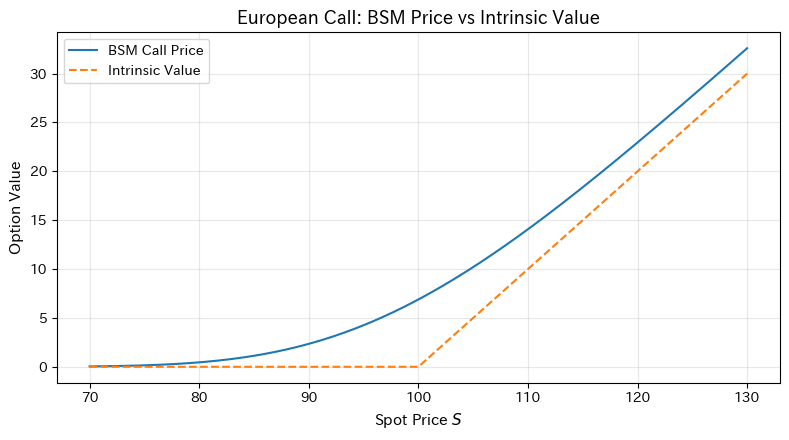

In [8]:
# --- 5-2. Option payoff 曲線 ---
S_range = np.linspace(70, 130, 200)
C_values = bsm_call_price(S_range, K_h, T_h, r_h, sigma_h)
intrinsic = np.maximum(S_range - K_h, 0)

fig, ax = plt.subplots()
ax.plot(S_range, C_values, label="BSM Call Price")
ax.plot(S_range, intrinsic, "--", label="Intrinsic Value")
ax.set_title("European Call: BSM Price vs Intrinsic Value")
ax.set_xlabel("Spot Price $S$")
ax.set_ylabel("Option Value")
ax.legend()
plt.tight_layout()
plt.show()

### 確認ポイント (Section 5)

1. Delta-hedged portfolio の P&L が $\delta S=0$ 付近で**ほぼゼロ**であることを確認しましたか？
2. $\delta S$ が大きくなるとヘッジ誤差が生じます。これは何に起因しますか？（ヒント: gamma）
3. BSM PDE に $\mu$ が現れないことの直感を、デルタヘッジの議論から説明してみましょう。

---
## 6. §15.7 リスク中立評価

### 理論

#### 実世界確率 vs リスク中立確率

* **実世界 (Physical measure, $\mathbb{P}$)**: 株価のドリフトは期待収益率 $\mu$ → 予測に使う。
* **リスク中立 (Risk-neutral measure, $\mathbb{Q}$)**: ドリフトを $r$ に置き換える → **価格付け**に使う。

$$
C = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}\!\left[\max(S_T - K, 0)\right]
$$

#### なぜ $\mu$ ではなく $r$ を使うのか

デルタヘッジにより確率的リターン成分が消え、ポートフォリオの期待成長率は $r$ になります。
したがって、「すべての資産が $r$ で成長する世界」で期待値を取り、$r$ で割引するのが正しい価格付けです。

> **価格付け** ≠ **予測**
> $\mu$ が高くても低くても、ヘッジ可能な範囲ではオプション価格は変わりません。

In [9]:
# --- 6-1. モンテカルロによる European Call 価格 ---

K_mc = 100.0
T_mc = 1.0
r_mc = 0.05
sigma_mc = 0.20
S0_mc = 100.0
n_mc = 100000

# リスク中立ドリフト r で生成
Z_mc = rng.standard_normal(n_mc)
ST_rn = S0_mc * np.exp((r_mc - 0.5 * sigma_mc**2) * T_mc + sigma_mc * np.sqrt(T_mc) * Z_mc)
payoff_rn = np.maximum(ST_rn - K_mc, 0)
mc_price_rn = np.exp(-r_mc * T_mc) * payoff_rn.mean()

# BSM 閉形式
bsm_exact = bsm_call_price(S0_mc, K_mc, T_mc, r_mc, sigma_mc)

print(f"Monte Carlo (drift=r) : {mc_price_rn:.4f}")
print(f"BSM closed-form       : {bsm_exact:.4f}")
print(f"差                    : {abs(mc_price_rn - bsm_exact):.4f}")

Monte Carlo (drift=r) : 10.4658
BSM closed-form       : 10.4506
差                    : 0.0152


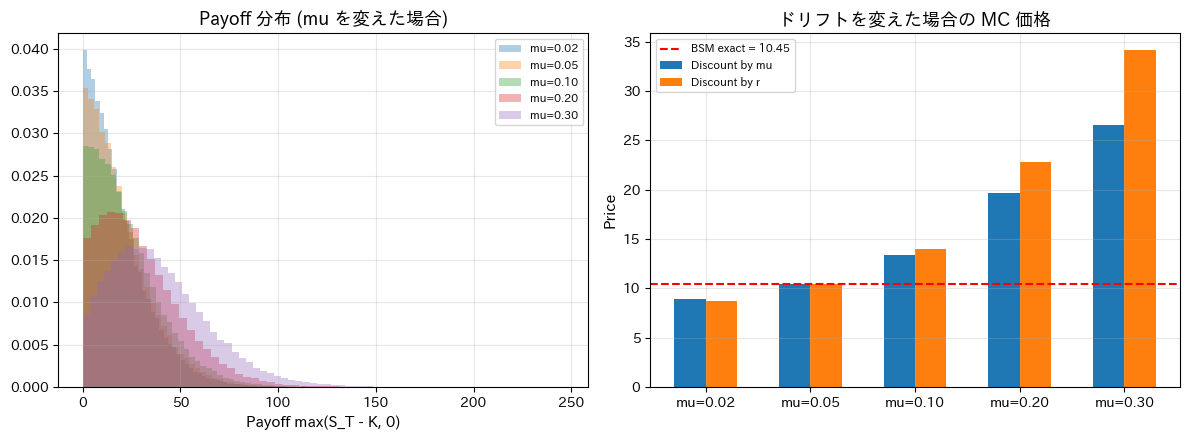

-> リスク中立 (drift=r) で作ったパスのみが BSM 価格と一致する


In [10]:
# --- 6-2. mu を変えたときの比較 ---

mu_values = [0.02, 0.05, 0.10, 0.20, 0.30]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

colors_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
mc_prices = []

for i, mu_i in enumerate(mu_values):
    Z_i = rng.standard_normal(n_mc)
    # 実世界ドリフト mu_i で株価を生成
    ST_i = S0_mc * np.exp((mu_i - 0.5 * sigma_mc**2) * T_mc + sigma_mc * np.sqrt(T_mc) * Z_i)
    payoff_i = np.maximum(ST_i - K_mc, 0)

    # (a) payoff 分布
    axes[0].hist(payoff_i[payoff_i > 0], bins=60, density=True, alpha=0.35,
                 label=f"mu={mu_i:.2f}", color=colors_cycle[i % len(colors_cycle)])

    # mu_i で割引 → 意味のない「価格」
    wrong_price = np.exp(-mu_i * T_mc) * payoff_i.mean()
    # r で割引 (しかし分布が mu_i ベース → 理論的に不正確)
    also_wrong = np.exp(-r_mc * T_mc) * payoff_i.mean()
    mc_prices.append((mu_i, wrong_price, also_wrong))

axes[0].set_title("Payoff 分布 (mu を変えた場合)")
axes[0].set_xlabel("Payoff max(S_T - K, 0)")
axes[0].legend(fontsize=8)

# (b) 各 mu での「価格」
df_mc = pd.DataFrame(mc_prices, columns=["mu", "disc_by_mu", "disc_by_r"])
axes[1].bar(np.arange(len(mu_values)) - 0.15, df_mc["disc_by_mu"], 0.3, label="Discount by mu")
axes[1].bar(np.arange(len(mu_values)) + 0.15, df_mc["disc_by_r"], 0.3, label="Discount by r")
axes[1].axhline(bsm_exact, color="red", linestyle="--", label=f"BSM exact = {bsm_exact:.2f}")
axes[1].set_xticks(np.arange(len(mu_values)))
axes[1].set_xticklabels([f"mu={m:.2f}" for m in mu_values])
axes[1].set_title("ドリフトを変えた場合の MC 価格")
axes[1].set_ylabel("Price")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("-> リスク中立 (drift=r) で作ったパスのみが BSM 価格と一致する")

### 確認ポイント (Section 6)

1. ドリフトを $r$ として生成し $r$ で割引した MC 価格が BSM 閉形式と近いことを確認しましたか？
2. $\mu \neq r$ で株価を生成し、$r$ で割引すると**不正確**な値になることを確認しましたか？
3. 「価格付けと予測は違う」という命題を、数値実験から自分の言葉で説明してみましょう。

---
## 7. §15.8 BSM 公式の実装

### 理論

European call / put の BSM 価格:

$$
C = S\,N(d_1) - K\,e^{-rT}\,N(d_2)
$$

$$
P = K\,e^{-rT}\,N(-d_2) - S\,N(-d_1)
$$

ここで

$$
d_1 = \frac{\ln(S/K) + (r + \sigma^2/2)\,T}{\sigma\sqrt{T}}, \qquad
d_2 = d_1 - \sigma\sqrt{T}
$$

### $d_1$, $d_2$ の直感的意味

* $N(d_2)$ はリスク中立確率下での $S_T > K$（オプションが ITM で終わる）の確率に相当。
* $N(d_1)$ は $\Delta$（デルタ）に等しく、ヘッジ比率を表す。
  感覚的には $d_1 = d_2 + \sigma\sqrt{T}$ の分だけ「確率が上にずれる」。

### Put-Call Parity

$$
C - P = S - K\,e^{-rT}
$$

In [11]:
# --- 7-1. サンプルパラメータで価格計算 ---

S_ex = 100.0
K_ex = 100.0
T_ex = 1.0
r_ex = 0.05
sigma_ex = 0.20

d1, d2 = bsm_d1_d2(S_ex, K_ex, T_ex, r_ex, sigma_ex)
C_ex = bsm_call_price(S_ex, K_ex, T_ex, r_ex, sigma_ex)
P_ex = bsm_put_price(S_ex, K_ex, T_ex, r_ex, sigma_ex)
parity_res = put_call_parity_gap(S_ex, K_ex, T_ex, r_ex, C_ex, P_ex)

print(f"d1 = {d1:.6f}")
print(f"d2 = {d2:.6f}")
print(f"Call price = {C_ex:.6f}")
print(f"Put  price = {P_ex:.6f}")
print(f"Put-Call Parity residual = {parity_res:.2e}")

d1 = 0.350000
d2 = 0.150000
Call price = 10.450584
Put  price = 5.573526
Put-Call Parity residual = 0.00e+00


In [12]:
# --- [Sanity] 7-1. Put-call parity の残差確認  [updated: sanity check] ---
pcp_res = put_call_parity_gap(S_ex, K_ex, T_ex, r_ex, C_ex, P_ex)
print(f"Put-Call Parity Residual = {pcp_res:.2e}")
assert abs(pcp_res) < 1e-12, f"Put-call parity が成立していません: {pcp_res}"
print("-> OK: 残差が数値誤差 (< 1e-12) に収まっています")


Put-Call Parity Residual = 0.00e+00
-> OK: 残差が数値誤差 (< 1e-12) に収まっています


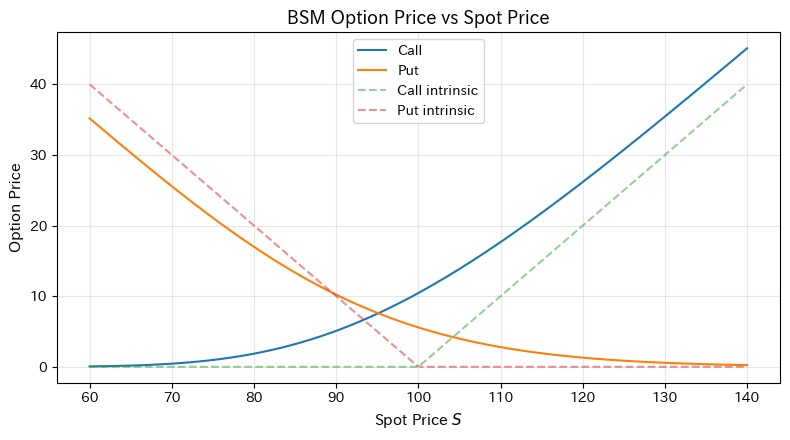

In [13]:
# --- 7-2. Option price vs Spot ---
S_arr = np.linspace(60, 140, 200)
C_arr = bsm_call_price(S_arr, K_ex, T_ex, r_ex, sigma_ex)
P_arr = bsm_put_price(S_arr, K_ex, T_ex, r_ex, sigma_ex)

fig, ax = plt.subplots()
ax.plot(S_arr, C_arr, label="Call")
ax.plot(S_arr, P_arr, label="Put")
ax.plot(S_arr, np.maximum(S_arr - K_ex, 0), "--", alpha=0.5, label="Call intrinsic")
ax.plot(S_arr, np.maximum(K_ex - S_arr, 0), "--", alpha=0.5, label="Put intrinsic")
ax.set_title("BSM Option Price vs Spot Price")
ax.set_xlabel("Spot Price $S$")
ax.set_ylabel("Option Price")
ax.legend()
plt.tight_layout()
plt.show()

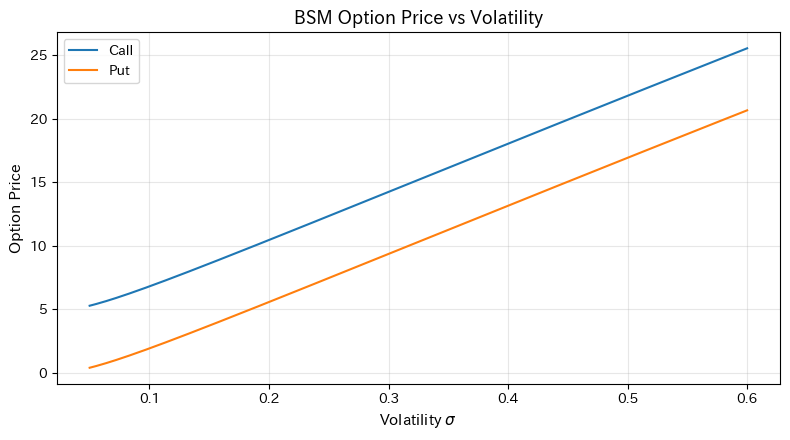

In [14]:
# --- 7-3. Option price vs Volatility ---
sigma_arr = np.linspace(0.05, 0.60, 200)
C_sigma = [bsm_call_price(S_ex, K_ex, T_ex, r_ex, s) for s in sigma_arr]
P_sigma = [bsm_put_price(S_ex, K_ex, T_ex, r_ex, s) for s in sigma_arr]

fig, ax = plt.subplots()
ax.plot(sigma_arr, C_sigma, label="Call")
ax.plot(sigma_arr, P_sigma, label="Put")
ax.set_title("BSM Option Price vs Volatility")
ax.set_xlabel(r"Volatility $\sigma$")
ax.set_ylabel("Option Price")
ax.legend()
plt.tight_layout()
plt.show()

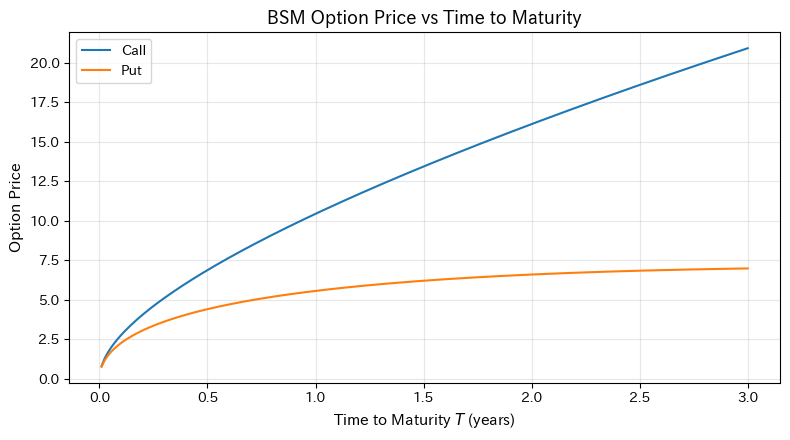

In [15]:
# --- 7-4. Option price vs Maturity ---
T_arr = np.linspace(0.01, 3.0, 200)
C_T = [bsm_call_price(S_ex, K_ex, t, r_ex, sigma_ex) for t in T_arr]
P_T = [bsm_put_price(S_ex, K_ex, t, r_ex, sigma_ex) for t in T_arr]

fig, ax = plt.subplots()
ax.plot(T_arr, C_T, label="Call")
ax.plot(T_arr, P_T, label="Put")
ax.set_title("BSM Option Price vs Time to Maturity")
ax.set_xlabel("Time to Maturity $T$ (years)")
ax.set_ylabel("Option Price")
ax.legend()
plt.tight_layout()
plt.show()

### 確認ポイント (Section 7)

1. Put-Call Parity の残差が数値誤差 ($\approx 10^{-15}$) に収まることを確認しましたか？
2. Spot が上がると Call は上がり Put は下がることをグラフで確認しましょう。
3. $\sigma$ が大きくなると Call/Put の両方が高くなる理由を説明できますか？

---
## 8. §15.9 累積標準正規分布 $N(x)$

### 理論

$N(x)$ は標準正規分布の CDF です:

$$
N(x) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{x} e^{-z^2/2}\,dz
$$

BSM 公式において:

* $N(d_2)$ — **リスク中立確率下でオプションが ITM で満期を迎える確率**に関連する量。
* $N(d_1)$ — **デルタ（ヘッジ比率）**に等しい。$d_1 = d_2 + \sigma\sqrt{T}$ の関係から、$N(d_1) > N(d_2)$。

$N(d_1)$ は正確には「デジタルアセットオプション(asset-or-nothing)の行使確率」と解釈でき、ヘッジ比率はこの値に一致します。

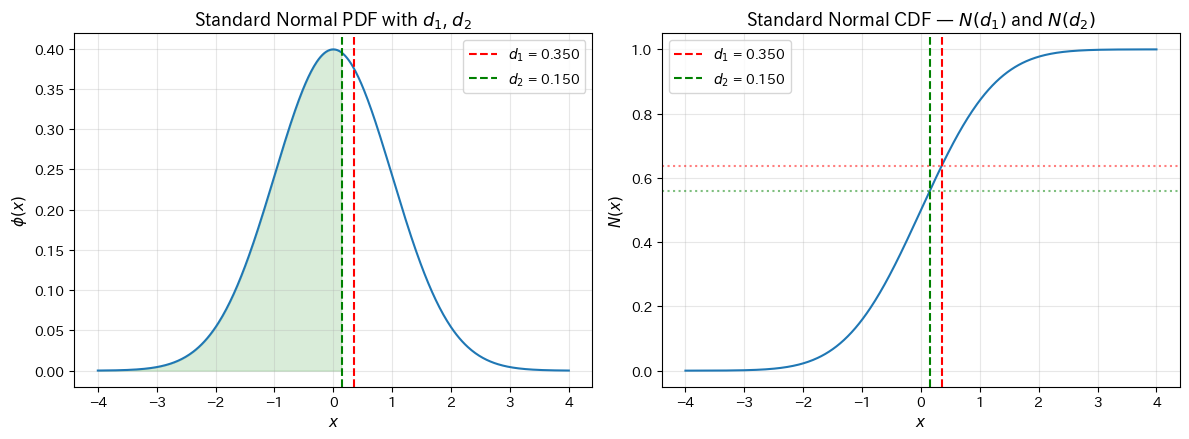

N(d1) = 0.636831  (= Call Delta)
N(d2) = 0.559618  (~ RN prob of S_T > K)


In [16]:
# --- 8-1. 標準正規 pdf / cdf の描画 ---

x_norm = np.linspace(-4, 4, 500)

# d1, d2 の値（Section 7 のサンプル）
d1_mark, d2_mark = bsm_d1_d2(S_ex, K_ex, T_ex, r_ex, sigma_ex)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) pdf
axes[0].plot(x_norm, norm.pdf(x_norm), linewidth=1.5)
axes[0].axvline(d1_mark, color="red", linestyle="--", label=f"$d_1$ = {d1_mark:.3f}")
axes[0].axvline(d2_mark, color="green", linestyle="--", label=f"$d_2$ = {d2_mark:.3f}")
axes[0].fill_between(x_norm, norm.pdf(x_norm),
                     where=(x_norm <= d2_mark), alpha=0.15, color="green")
axes[0].set_title("Standard Normal PDF with $d_1$, $d_2$")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel(r"$\phi(x)$")
axes[0].legend()

# (b) cdf
axes[1].plot(x_norm, norm.cdf(x_norm), linewidth=1.5)
axes[1].axvline(d1_mark, color="red", linestyle="--", label=f"$d_1$ = {d1_mark:.3f}")
axes[1].axvline(d2_mark, color="green", linestyle="--", label=f"$d_2$ = {d2_mark:.3f}")
axes[1].axhline(norm.cdf(d1_mark), color="red", linestyle=":", alpha=0.5)
axes[1].axhline(norm.cdf(d2_mark), color="green", linestyle=":", alpha=0.5)
axes[1].set_title("Standard Normal CDF — $N(d_1)$ and $N(d_2)$")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel("$N(x)$")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"N(d1) = {norm.cdf(d1_mark):.6f}  (= Call Delta)")
print(f"N(d2) = {norm.cdf(d2_mark):.6f}  (~ RN prob of S_T > K)")

### 確認ポイント (Section 8)

1. $N(d_1)$ が Section 7 で計算した `bsm_call_delta` と一致することを確認しましたか？
2. ATM ($S=K$) の場合、$d_1$ と $d_2$ はゼロに近いですか？なぜですか？
3. $\sigma$ を大きくすると $d_1 - d_2 = \sigma\sqrt{T}$ が広がることを確認しましょう。

---
## 9. §15.10 ワラントと従業員ストックオプション (ESO)

### 理論

* **ワラント**: 企業が発行するコール・オプション。行使されると新株が発行されるため**希薄化 (dilution)** が生じる。
* **従業員ストックオプション (ESO)**: ワラントと同様に希薄化の影響がある。

希薄化の効果:
* 発行済み株式数 $N$、ワラント数 $M$、行使価格 $K$ とする。
* 行使後の 1 株価値は $(N \cdot S + M \cdot K) / (N + M)$ となり、行使前の $S$ より下がる。
* ワラント 1 本の価値は通常のコール価格に $\frac{N}{N+M}$ を掛けたものになる。

### 通常の European Call との違い

* 通常のコール: 行使しても新株は発行されない → 希薄化なし。
* ワラント/ESO: 行使 → 新株発行 → 既存株主の持分が薄まる。

In [17]:
# --- 9-1. 希薄化デモ ---

N_shares = 1_000_000          # 発行済み株式数
M_warrants = 100_000          # ワラント数
S_current = 50.0              # 現在の株価
K_warrant = 45.0              # 行使価格

# 希薄化前の企業価値
firm_value_before = N_shares * S_current

# ワラント全行使後
cash_in = M_warrants * K_warrant
firm_value_after = firm_value_before + cash_in
total_shares = N_shares + M_warrants
S_after = firm_value_after / total_shares

print(f"希薄化前の 1 株価値 : {S_current:.2f}")
print(f"希薄化後の 1 株価値 : {S_after:.2f}")
print(f"希薄化による価値減少: {S_current - S_after:.2f}  ({(S_current - S_after)/S_current*100:.1f}%)")

# BSM での通常のコール価格
T_w = 2.0; r_w = 0.05; sigma_w = 0.30
call_plain = bsm_call_price(S_current, K_warrant, T_w, r_w, sigma_w)
warrant_adjusted = call_plain * N_shares / (N_shares + M_warrants)

print(f"\n通常の BSM Call 価格       : {call_plain:.4f}")
print(f"希薄化調整後ワラント価格  : {warrant_adjusted:.4f}")
print(f"調整係数 N/(N+M)          : {N_shares/(N_shares+M_warrants):.4f}")

希薄化前の 1 株価値 : 50.00
希薄化後の 1 株価値 : 49.55
希薄化による価値減少: 0.45  (0.9%)

通常の BSM Call 価格       : 13.1201
希薄化調整後ワラント価格  : 11.9273
調整係数 N/(N+M)          : 0.9091


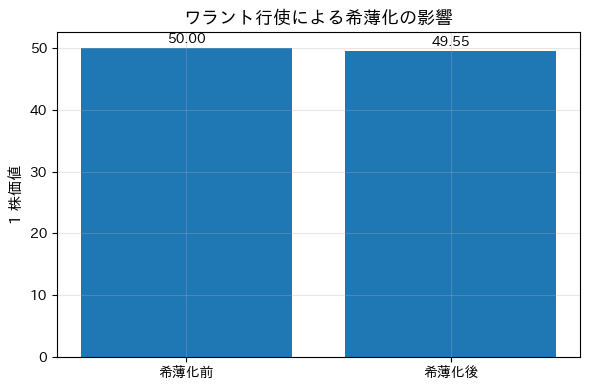

In [18]:
# --- 9-2. 希薄化前後の 1株価値 比較図 ---

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["希薄化前", "希薄化後"], [S_current, S_after])
ax.set_ylabel("1 株価値")
ax.set_title("ワラント行使による希薄化の影響")

# 値をバーの上に表示
for bar, val in zip(bars, [S_current, S_after]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.2f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()

### 確認ポイント (Section 9)

1. ワラント数 $M$ を変えると希薄化の程度がどう変わるか試してみましょう。
2. $M=0$ の場合、ワラント価格と通常のコール価格が一致することを確認しましょう。
3. なぜ ESO の費用計上が複雑なのか、希薄化の観点から考えてみましょう。

---
## 10. §15.11 インプライド・ボラティリティ

### 理論

**インプライド・ボラティリティ (IV)** は、BSM 公式に市場で観測されたオプション価格を代入し、逆にボラティリティを求めたものです。

$$
C_{\text{market}} = C_{\text{BSM}}(S, K, T, r, \sigma_{\text{IV}}) \quad \Longrightarrow \quad \sigma_{\text{IV}} = ?
$$

BSM 公式は $\sigma$ の単調増加関数なので、一意の解が存在します。
求め方は **root-finding** を使います:

1. **二分法 (Bisection)**: 安定だが収束が遅い。
2. **Newton-Raphson 法**: Vega を利用して高速収束。

### なぜ Price より IV で会話するのか

* 異なるストライクや満期で比較しやすい（正規化されている）。
* IV は市場参加者の「不確実性」の見方を直接反映する。
* **Volatility Smile/Skew** (Ch.20) への入口。

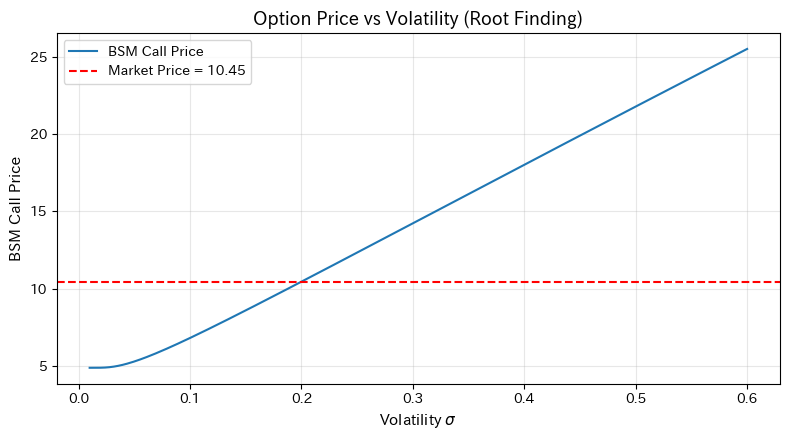

In [19]:
# --- 10-1. Option price vs volatility (root finding の可視化) ---

# ターゲット: BSM Call = 10.45
S_iv = 100.0; K_iv = 100.0; T_iv = 1.0; r_iv = 0.05
target_price = 10.45

sigma_grid = np.linspace(0.01, 0.60, 300)
prices_grid = [bsm_call_price(S_iv, K_iv, T_iv, r_iv, s) for s in sigma_grid]

fig, ax = plt.subplots()
ax.plot(sigma_grid, prices_grid, label="BSM Call Price")
ax.axhline(target_price, color="red", linestyle="--", label=f"Market Price = {target_price}")
ax.set_title("Option Price vs Volatility (Root Finding)")
ax.set_xlabel(r"Volatility $\sigma$")
ax.set_ylabel("BSM Call Price")
ax.legend()
plt.tight_layout()
plt.show()

Bisection IV = 0.19998445  (30 iters, converged=True)
Newton    IV = 0.19998445  (4 iters, converged=True)
Bisection: 収束しました
Newton:    収束しました


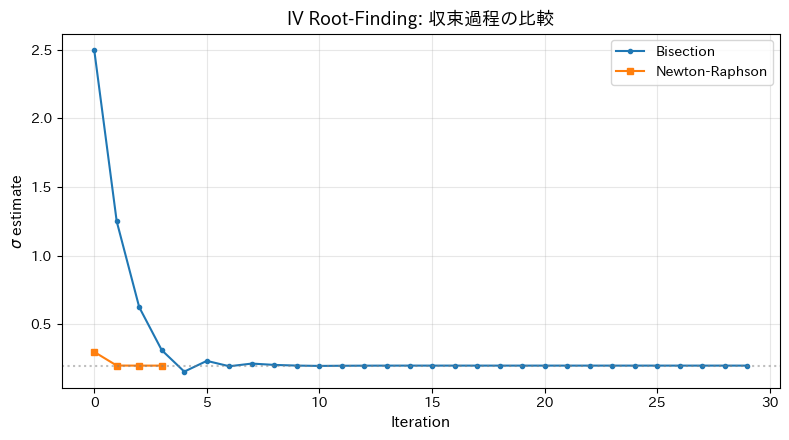

In [20]:
# --- 10-2. Bisection vs Newton 収束比較  [updated: dict 形式に対応] ---

res_bi = implied_vol_bisection(target_price, S_iv, K_iv, T_iv, r_iv)
res_nw = implied_vol_newton(target_price, S_iv, K_iv, T_iv, r_iv)

iv_bi  = res_bi["iv"]
hist_bi = res_bi["history"]
iv_nw  = res_nw["iv"]
hist_nw = res_nw["history"]

print(f"Bisection IV = {iv_bi:.8f}  ({res_bi['iterations']} iters, converged={res_bi['converged']})")
print(f"Newton    IV = {iv_nw:.8f}  ({res_nw['iterations']} iters, converged={res_nw['converged']})")
print(f"Bisection: {res_bi['message']}")
print(f"Newton:    {res_nw['message']}")

fig, ax = plt.subplots()
ax.plot(range(len(hist_bi)), hist_bi, "o-", markersize=3, label="Bisection")
ax.plot(range(len(hist_nw)), hist_nw, "s-", markersize=4, label="Newton-Raphson")
ax.axhline(iv_bi, color="gray", linestyle=":", alpha=0.5)
ax.set_title("IV Root-Finding: 収束過程の比較")
ax.set_xlabel("Iteration")
ax.set_ylabel(r"$\sigma$ estimate")
ax.legend()
plt.tight_layout()
plt.show()


In [21]:
# --- [Sanity] 10-2. IV round-trip 確認  [updated: sanity check] ---
# 逆算した IV を再度 BSM に入れると元の市場価格に戻ることを確認
roundtrip_price = bsm_call_price(S_iv, K_iv, T_iv, r_iv, iv_bi)
print(f"Round-trip: target={target_price:.6f}, BSM(IV)={roundtrip_price:.6f}, "
      f"diff={abs(roundtrip_price - target_price):.2e}")
assert abs(roundtrip_price - target_price) < 1e-6, "IV round-trip の残差が許容誤差を超えています"
print("-> OK: IV round-trip の残差が 1e-6 以内です")


Round-trip: target=10.450000, BSM(IV)=10.450000, diff=6.40e-09
-> OK: IV round-trip の残差が 1e-6 以内です


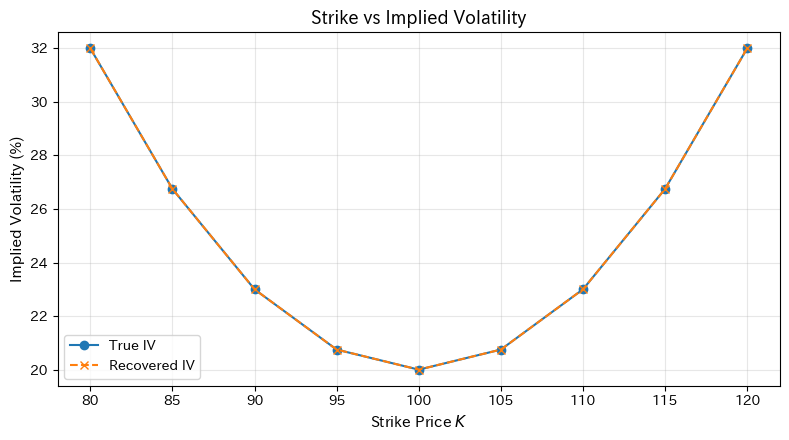

-> BSM では sigma 一定を仮定するが、市場では Strike ごとに IV が異なる (Volatility Smile)


In [22]:
# --- 10-3. Strike 別 IV (Volatility Smile の入口) ---

# サンプルの市場オプション価格（人工データ: 軽い U字型 smile を仕込む）
strikes = np.array([80, 85, 90, 95, 100, 105, 110, 115, 120])
true_ivs = 0.20 + 0.0003 * (strikes - 100)**2  # 簡単な U 字型 smile

# 対応する市場価格を BSM で計算
market_prices = np.array([
    bsm_call_price(S_iv, k, T_iv, r_iv, iv) for k, iv in zip(strikes, true_ivs)
])

# IV を逆算  [updated: dict 形式に対応]
recovered_ivs = []
for k, mp in zip(strikes, market_prices):
    res = implied_vol_bisection(mp, S_iv, k, T_iv, r_iv)
    recovered_ivs.append(res["iv"])
recovered_ivs = np.array(recovered_ivs)

fig, ax = plt.subplots()
ax.plot(strikes, true_ivs * 100, "o-", label="True IV")
ax.plot(strikes, recovered_ivs * 100, "x--", label="Recovered IV")
ax.set_title("Strike vs Implied Volatility")
ax.set_xlabel("Strike Price $K$")
ax.set_ylabel("Implied Volatility (%)")
ax.legend()
plt.tight_layout()
plt.show()

print("-> BSM では sigma 一定を仮定するが、市場では Strike ごとに IV が異なる (Volatility Smile)")


> **Volatility Smile に関する補足**
>
> ここで使っているデータは **人工データ** です（ATM IV = 20%、U字型 smile を仮定）。
> 実際の市場では資産クラスによって形が大きく異なります。
>
> | 資産クラス | 典型的な形 | 主な背景 |
> |---|---|---|
> | **Equity Index**（日経、S&P など） | 左右非対称の **スキュー**（低 Strike 側の IV が高い） | クラッシュリスクへの需要；レバレッジ効果 |
> | **FX** | ほぼ対称な **Smile** | 双方向のテールリスク |
> | **Interest Rate Cap/Floor** | フラットまたは右上がり | 高金利方向の不確実性 |
>
> Equity index では一般に **「OTM put の IV が高い（左スキュー）」** が観測されます。
> 本 Notebook の U 字型 smile は説明のための简化モデルです。
>
> BSM の定数ボラティリティ仮定を超えた**ボラティリティ曲面モデル（SVI, SABR など）**は
> **Chapter 20** で詳しく扱います。


### 確認ポイント (Section 10)

1. Newton 法が Bisection 法より大幅に少ない反復で収束することを確認しましたか？
2. Strike が ATM から離れるほど IV が高くなる（U字型）パターンが見えますか？
   これが **Volatility Smile** の入口です (Ch.20 で詳しく学びます)。
3. Vega が非常に小さい（deep OTM/ITM）場合、Newton 法が不安定になる理由を考えてみましょう。

---
## 11. §15.12 配当

### 理論

配当利回り $q$ を持つ株式に対する BSM 拡張:

$$
C = S\,e^{-qT}\,N(d_1) - K\,e^{-rT}\,N(d_2)
$$
$$
P = K\,e^{-rT}\,N(-d_2) - S\,e^{-qT}\,N(-d_1)
$$
$$
d_1 = \frac{\ln(S/K) + (r - q + \sigma^2/2)\,T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}
$$

### 配当の直感

* **Call は配当で下がる**: 配当は株価の「漏れ」→ 将来の期待株価が下がる → Call 価値↓
* **Put は配当で上がる**: 株価が下がりやすくなる → Put 価値↑

### 欧州型 vs 米国型（短いコメント）

* 欧州型のコールは配当がなければ早期行使が最適にならない。
* 配当がある場合、配当落ち直前の早期行使が有利になり得る → 米国型の方が価値が高い。

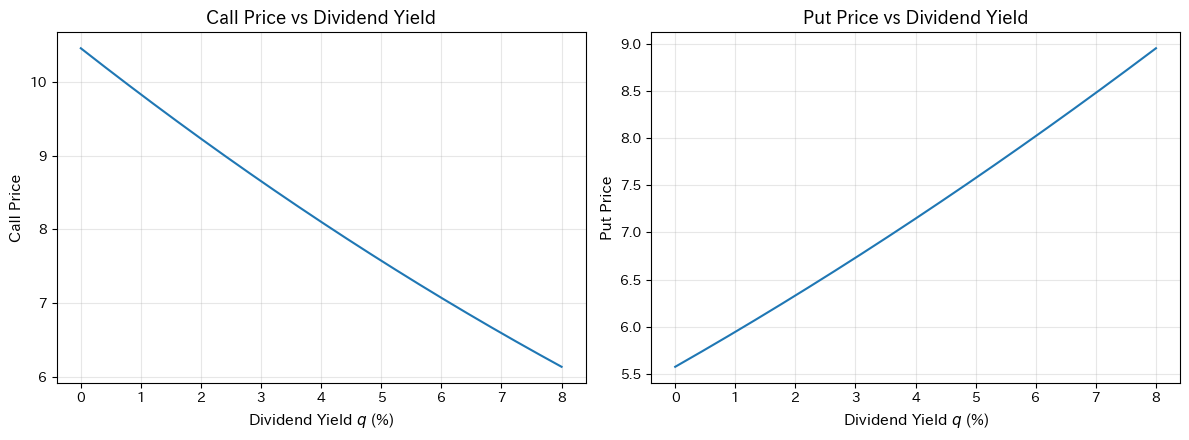

In [23]:
# --- 11-1. q を変えたときの Call / Put 価格 ---

q_arr = np.linspace(0, 0.08, 200)
C_q = [bsm_call_with_dividend_yield(S_ex, K_ex, T_ex, r_ex, sigma_ex, q) for q in q_arr]
P_q = [bsm_put_with_dividend_yield(S_ex, K_ex, T_ex, r_ex, sigma_ex, q) for q in q_arr]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(q_arr * 100, C_q)
axes[0].set_title("Call Price vs Dividend Yield")
axes[0].set_xlabel("Dividend Yield $q$ (%)")
axes[0].set_ylabel("Call Price")

axes[1].plot(q_arr * 100, P_q)
axes[1].set_title("Put Price vs Dividend Yield")
axes[1].set_xlabel("Dividend Yield $q$ (%)")
axes[1].set_ylabel("Put Price")

plt.tight_layout()
plt.show()

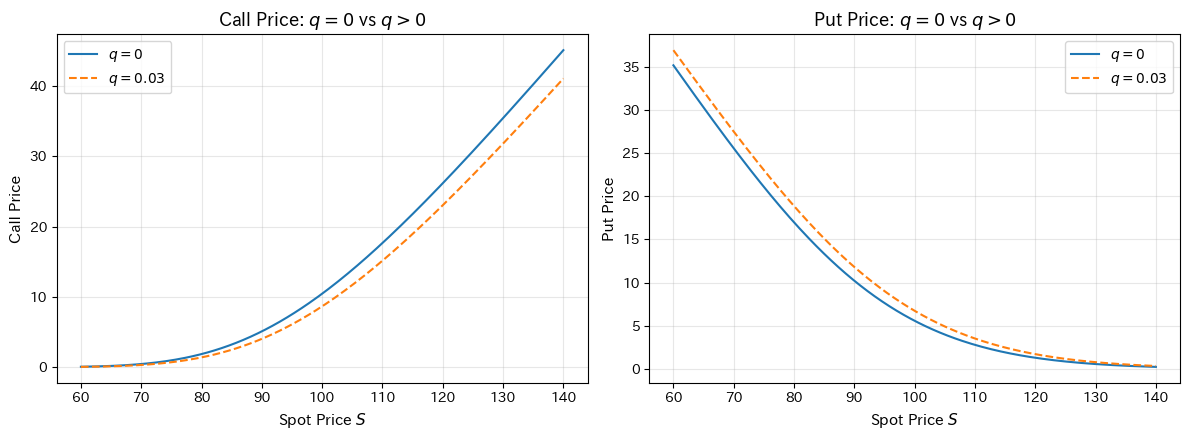

ATM (S=100) での比較:
  Call q=0: 10.4506
  Call q=3%: 8.6525
  Put  q=0: 5.5735
  Put  q=3%: 6.7309


In [24]:
# --- 11-2. q=0 vs q>0 の比較 ---

S_arr2 = np.linspace(60, 140, 200)
q_val = 0.03

C_q0 = bsm_call_price(S_arr2, K_ex, T_ex, r_ex, sigma_ex)  # q=0
C_q3 = np.array([bsm_call_with_dividend_yield(s, K_ex, T_ex, r_ex, sigma_ex, q_val)
                  for s in S_arr2])
P_q0 = bsm_put_price(S_arr2, K_ex, T_ex, r_ex, sigma_ex)
P_q3 = np.array([bsm_put_with_dividend_yield(s, K_ex, T_ex, r_ex, sigma_ex, q_val)
                  for s in S_arr2])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(S_arr2, C_q0, label="$q=0$")
axes[0].plot(S_arr2, C_q3, "--", label=f"$q={q_val}$")
axes[0].set_title("Call Price: $q=0$ vs $q>0$")
axes[0].set_xlabel("Spot Price $S$")
axes[0].set_ylabel("Call Price")
axes[0].legend()

axes[1].plot(S_arr2, P_q0, label="$q=0$")
axes[1].plot(S_arr2, P_q3, "--", label=f"$q={q_val}$")
axes[1].set_title("Put Price: $q=0$ vs $q>0$")
axes[1].set_xlabel("Spot Price $S$")
axes[1].set_ylabel("Put Price")
axes[1].legend()

plt.tight_layout()
plt.show()

# 数値確認
print("ATM (S=100) での比較:")
print(f"  Call q=0: {bsm_call_price(100, 100, 1, 0.05, 0.20):.4f}")
print(f"  Call q=3%: {bsm_call_with_dividend_yield(100, 100, 1, 0.05, 0.20, 0.03):.4f}")
print(f"  Put  q=0: {bsm_put_price(100, 100, 1, 0.05, 0.20):.4f}")
print(f"  Put  q=3%: {bsm_put_with_dividend_yield(100, 100, 1, 0.05, 0.20, 0.03):.4f}")

In [25]:
# --- [Sanity] 11-2. q=0 での一致確認  [updated: sanity check] ---
# q=0 の dividend-adjusted BSM が通常 BSM と一致することを確認
_call_no_q   = bsm_call_price(100.0, 100.0, 1.0, 0.05, 0.20)
_call_zero_q = bsm_call_with_dividend_yield(100.0, 100.0, 1.0, 0.05, 0.20, q=0.0)
_put_no_q    = bsm_put_price(100.0, 100.0, 1.0, 0.05, 0.20)
_put_zero_q  = bsm_put_with_dividend_yield(100.0, 100.0, 1.0, 0.05, 0.20, q=0.0)
print(f"Call q=0 vs 通常 BSM: diff = {abs(_call_no_q - _call_zero_q):.2e}")
print(f"Put  q=0 vs 通常 BSM: diff = {abs(_put_no_q  - _put_zero_q):.2e}")
assert abs(_call_no_q - _call_zero_q) < 1e-12
assert abs(_put_no_q  - _put_zero_q ) < 1e-12
print("-> OK: q=0 の dividend-adjusted BSM が通常 BSM と一致しています")


Call q=0 vs 通常 BSM: diff = 0.00e+00
Put  q=0 vs 通常 BSM: diff = 0.00e+00
-> OK: q=0 の dividend-adjusted BSM が通常 BSM と一致しています


### 確認ポイント (Section 11)

1. $q$ が増えると Call が下がり Put が上がることをグラフで確認しましたか？
2. $q=0$ のとき `bsm_call_with_dividend_yield` と `bsm_call_price` が一致することを検証しましょう。
3. 米国型コールで配当落ち直前に早期行使が合理的になる理由を考えてみましょう。

---
## 12. 付録 15A の数値確認

### 目的

BSM 公式は、リスク中立測度下での期待値の closed-form solution です:

$$
C = e^{-rT}\,\mathbb{E}^{\mathbb{Q}}[\max(S_T - K, 0)]
$$

ここでは証明を再現するのではなく、**モンテカルロ法で期待値を直接計算し、BSM 閉形式と一致するかを数値的に確認**します。

In [26]:
# --- 12-1. Monte Carlo vs BSM ---

S0_a = 100.0; K_a = 100.0; T_a = 1.0; r_a = 0.05; sigma_a = 0.20
bsm_a = bsm_call_price(S0_a, K_a, T_a, r_a, sigma_a)

n_sims_list = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000, 500_000]
mc_estimates = []
rng_a = np.random.default_rng(123)

for n in n_sims_list:
    Z = rng_a.standard_normal(n)
    ST = S0_a * np.exp((r_a - 0.5 * sigma_a**2) * T_a + sigma_a * np.sqrt(T_a) * Z)
    payoff = np.maximum(ST - K_a, 0)
    mc_est = np.exp(-r_a * T_a) * payoff.mean()
    mc_estimates.append(mc_est)

print(f"BSM closed-form: {bsm_a:.6f}\n")
print(f"{'N':>10s}  {'MC Price':>10s}  {'Error':>10s}")
print("-" * 35)
for n, mc in zip(n_sims_list, mc_estimates):
    print(f"{n:>10,d}  {mc:>10.4f}  {mc - bsm_a:>+10.4f}")

BSM closed-form: 10.450584

         N    MC Price       Error
-----------------------------------
       100     10.4302     -0.0204
       500     10.6399     +0.1893
     1,000     10.7769     +0.3264
     5,000     10.4327     -0.0179
    10,000     10.5853     +0.1348
    50,000     10.4501     -0.0005
   100,000     10.4099     -0.0406
   500,000     10.4437     -0.0069


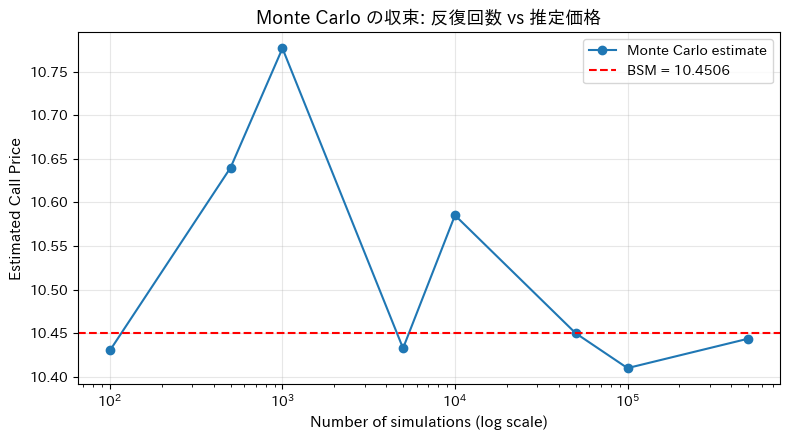

-> サンプル数を増やすと Monte Carlo 推定値は BSM 閉形式に収束する


In [27]:
# --- 12-2. 収束グラフ ---

fig, ax = plt.subplots()
ax.semilogx(n_sims_list, mc_estimates, "o-", label="Monte Carlo estimate")
ax.axhline(bsm_a, color="red", linestyle="--", label=f"BSM = {bsm_a:.4f}")
ax.set_title("Monte Carlo の収束: 反復回数 vs 推定価格")
ax.set_xlabel("Number of simulations (log scale)")
ax.set_ylabel("Estimated Call Price")
ax.legend()
plt.tight_layout()
plt.show()

print("-> サンプル数を増やすと Monte Carlo 推定値は BSM 閉形式に収束する")

In [28]:
# --- [Sanity] 12-2. MC 収束の確認  [updated: sanity check] ---
# 最大 N=500,000 での MC 価格が BSM と相対誤差 1% 以内に収まることを確認
_mc_large = mc_estimates[-1]
_rel_err  = abs(_mc_large - bsm_a) / bsm_a
print(f"BSM = {bsm_a:.6f},  MC (N=500k) = {_mc_large:.6f},  相対誤差 = {_rel_err:.4%}")
assert _rel_err < 0.01, f"MC 誤差が 1% を超えています: {_rel_err:.4%}"
print("-> OK: N=500,000 での MC 価格が BSM との相対誤差 1% 以内です")


BSM = 10.450584,  MC (N=500k) = 10.443682,  相対誤差 = 0.0660%
-> OK: N=500,000 での MC 価格が BSM との相対誤差 1% 以内です


### 確認ポイント (Section 12)

1. $N=500{,}000$ で BSM との差が小数第 2 位で一致しましたか？
2. Monte Carlo の収束レートは $O(1/\sqrt{N})$ です。$N$ を 4 倍にすると誤差は約半分になることを確認しましょう。
3. 分散削減手法（対称変量法や制御変量法）を適用したらどうなるか考えてみましょう。

---
## 13. 練習問題

以下の 5 問はこの Notebook 内で完結します。各問題の直後に解答例セルがあります。

### 問題 1: パラメータ変更時の価格変化

$S=100, K=105, T=0.5, r=0.03, \sigma=0.25$ での European Call 価格を計算し、
$\sigma$ を $0.15, 0.20, 0.25, 0.30, 0.35$ に変えたときの価格を表にしなさい。
$\sigma$ と Call 価格の関係を 1 文で説明しなさい。

In [29]:
# === 解答例 1 ===
S_q1, K_q1, T_q1, r_q1 = 100, 105, 0.5, 0.03
sigmas_q1 = [0.15, 0.20, 0.25, 0.30, 0.35]

print(f"{'sigma':>8s}  {'Call Price':>10s}")
print("-" * 22)
for s in sigmas_q1:
    c = bsm_call_price(S_q1, K_q1, T_q1, r_q1, s)
    print(f"{s:>8.2f}  {c:>10.4f}")

print("\n-> sigma が増加すると Call 価格は単調に増加する。")
print("  ボラティリティが高いほど大きな上昇の可能性が増え、Call の価値が高まる。")

   sigma  Call Price
----------------------
    0.15      2.8000
    0.20      4.1783
    0.25      5.5760
    0.30      6.9821
    0.35      8.3918

-> sigma が増加すると Call 価格は単調に増加する。
  ボラティリティが高いほど大きな上昇の可能性が増え、Call の価値が高まる。


### 問題 2: インプライド・ボラティリティの逆算

$S=110, K=100, T=0.25, r=0.04$ で、市場価格が $C=14.50$ のとき、
Bisection 法と Newton 法で IV を求めなさい。反復回数を比較しなさい。

In [30]:
# === 解答例 2 ===  [updated: dict 形式に対応]
S_q2, K_q2, T_q2, r_q2 = 110, 100, 0.25, 0.04
C_market_q2 = 14.50

res_bi_q2 = implied_vol_bisection(C_market_q2, S_q2, K_q2, T_q2, r_q2)
res_nw_q2 = implied_vol_newton(C_market_q2, S_q2, K_q2, T_q2, r_q2)
iv_bi_q2  = res_bi_q2["iv"]
iv_nw_q2  = res_nw_q2["iv"]

print(f"Bisection: IV = {iv_bi_q2:.6f}  ({res_bi_q2['iterations']} iters, converged={res_bi_q2['converged']})")
print(f"Newton:    IV = {iv_nw_q2:.6f}  ({res_nw_q2['iterations']} iters, converged={res_nw_q2['converged']})")
print(f"\n-> Newton 法の方が圧倒的に少ない反復回数で収束する。")
print(f"-> Bisection: {res_bi_q2['message']}")
print(f"-> Newton:    {res_nw_q2['message']}")


Bisection: IV = 0.375117  (32 iters, converged=True)
Newton:    IV = 0.375117  (4 iters, converged=True)

-> Newton 法の方が圧倒的に少ない反復回数で収束する。
-> Bisection: 収束しました
-> Newton:    収束しました


### 問題 3: Put-Call Parity の確認

$S=95, K=100, T=1.0, r=0.05, \sigma=0.20$ で Call と Put を BSM で計算し、
Put-Call Parity $C - P = S - Ke^{-rT}$ が成立することを数値で確認しなさい。

In [31]:
# === 解答例 3 ===
S_q3, K_q3, T_q3, r_q3, sigma_q3 = 95, 100, 1.0, 0.05, 0.20
C_q3 = bsm_call_price(S_q3, K_q3, T_q3, r_q3, sigma_q3)
P_q3 = bsm_put_price(S_q3, K_q3, T_q3, r_q3, sigma_q3)
parity_q3 = put_call_parity_gap(S_q3, K_q3, T_q3, r_q3, C_q3, P_q3)

print(f"Call = {C_q3:.6f}")
print(f"Put  = {P_q3:.6f}")
print(f"C - P             = {C_q3 - P_q3:.6f}")
print(f"S - K*exp(-rT)    = {S_q3 - K_q3 * np.exp(-r_q3 * T_q3):.6f}")
print(f"Parity residual   = {parity_q3:.2e}")
print("\n-> 残差は浮動小数点精度 (~1e-15) で、Parity は完全に成立している。")

Call = 7.510872
Put  = 7.633815
C - P             = -0.122942
S - K*exp(-rT)    = -0.122942
Parity residual   = 0.00e+00

-> 残差は浮動小数点精度 (~1e-15) で、Parity は完全に成立している。


### 問題 4: ローリングボラティリティの比較

Section 4 の価格系列に対し、窓長 10, 30, 60 日のローリングボラティリティを計算し、
1 つのグラフに重ねてプロットしなさい。窓長が推定に与える影響を述べなさい。

Section 4 の prices を再利用しています


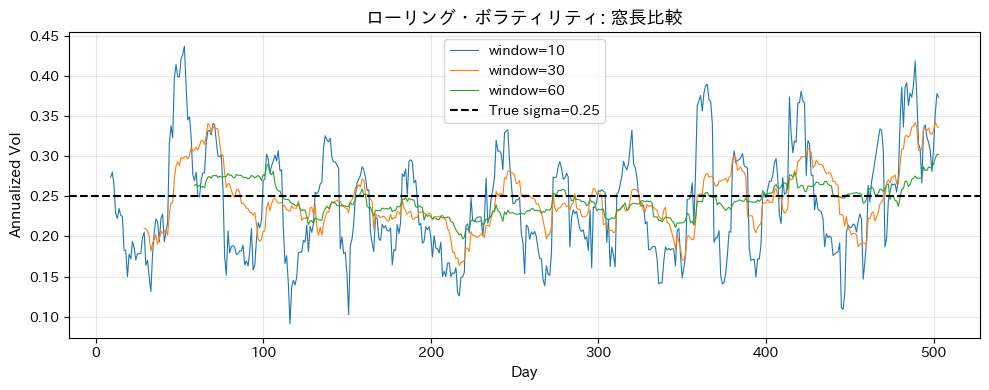

-> 窓長が短いほどノイジーだが局所変動を捉えやすい。
   窓長が長いほど滑らかだが変化への反応が遅い。


In [32]:
# === 解答例 4 ===  [updated: self-contained]
# prices が未定義の場合 (Section 4 を飛ばして実行した場合) に再生成する
try:
    _ = prices
    _prices_src = "Section 4 の prices を再利用しています"
except NameError:
    _, _S_tmp = simulate_gbm_paths(100.0, 0.10, 0.25, 2.0, 504, 1, np.random.default_rng(42))
    prices = _S_tmp[0]
    _prices_src = "Note: prices を Exercise 4 内で再生成しました (sigma=0.25, T=2y, 504日)"

print(_prices_src)

log_ret_q4 = compute_log_returns(prices)
series_q4 = pd.Series(log_ret_q4)

fig, ax = plt.subplots(figsize=(10, 4))
for w in [10, 30, 60]:
    rv = series_q4.rolling(window=w).std() * np.sqrt(252)
    ax.plot(rv.values, label=f"window={w}", linewidth=0.8)
ax.axhline(0.25, color="black", linestyle="--", label="True sigma=0.25")
ax.set_title("ローリング・ボラティリティ: 窓長比較")
ax.set_xlabel("Day")
ax.set_ylabel("Annualized Vol")
ax.legend()
plt.tight_layout()
plt.show()

print("-> 窓長が短いほどノイジーだが局所変動を捉えやすい。")
print("   窓長が長いほど滑らかだが変化への反応が遅い。")


### 問題 5: デルタヘッジ誤差の確認

$S=100, K=100, T=0.5, r=0.05, \sigma=0.20$ で European Call を 1 単位 short。
デルタ数の株を long してヘッジし、$S$ が $\pm 10$ 動いたときの P&L を計算しなさい。
$\delta S = \pm 1, \pm 5, \pm 10$ での hedged P&L を表にまとめ、
「ヘッジ誤差は $\delta S$ の 2 乗に比例する」ことを確認しなさい。

In [33]:
# === 解答例 5 ===
S_q5, K_q5, T_q5, r_q5, sigma_q5 = 100, 100, 0.5, 0.05, 0.20
C_q5 = bsm_call_price(S_q5, K_q5, T_q5, r_q5, sigma_q5)
delta_q5 = bsm_call_delta(S_q5, K_q5, T_q5, r_q5, sigma_q5)

dS_list = [-10, -5, -1, 1, 5, 10]
print(f"{'dS':>5s}  {'Hedged P&L':>12s}  {'dS^2':>6s}")
print("-" * 28)
for dS in dS_list:
    S_new = S_q5 + dS
    C_new = bsm_call_price(S_new, K_q5, T_q5, r_q5, sigma_q5)
    pnl_hedged = -(C_new - C_q5) + delta_q5 * dS
    print(f"{dS:>5d}  {pnl_hedged:>12.4f}  {dS**2:>6d}")

print("\n-> Hedged P&L は |dS| が大きくなると急に大きくなる。")
print("  これは Gamma (2次の効果) に起因し、誤差は概ね dS^2 に比例する。")

   dS    Hedged P&L    dS^2
----------------------------
  -10       -1.4380     100
   -5       -0.3545      25
   -1       -0.0138       1
    1       -0.0135       1
    5       -0.3239      25
   10       -1.2093     100

-> Hedged P&L は |dS| が大きくなると急に大きくなる。
  これは Gamma (2次の効果) に起因し、誤差は概ね dS^2 に比例する。


---
## 14. まとめ

### この Notebook で学んだこと

1. **株価過程**: GBM の仮定から、$\ln S_T$ が正規分布、$S_T$ が対数正規分布に従うことを確認した。
2. **ボラティリティ**: 対数収益率から実現ボラティリティを推定する方法と、ローリング推定の特性を学んだ。
3. **デルタヘッジと BSM PDE**: デルタヘッジにより確率項が消え、BSM PDE が導かれる直感を得た。PDE に $\mu$ が現れない理由を理解した。
4. **リスク中立評価**: 価格付けではドリフトを $r$ に置き換えること、そしてそれが予測とは異なることを数値実験で確認した。
5. **BSM 公式**: Call / Put の閉形式を実装し、Put-Call Parity の成立を検証した。$d_1, d_2$ の直感を整理した。
6. **$N(x)$ の役割**: $N(d_2)$ をリスク中立確率、$N(d_1)$ をデルタと結びつける解釈を学んだ。
7. **ワラントと ESO**: 希薄化の影響を定量的に確認した。
8. **インプライド・ボラティリティ**: Bisection 法と Newton 法による root-finding を実装し、収束を比較した。Volatility Smile の存在を確認した。
9. **配当**: 配当利回り $q$ を含む BSM 拡張を実装し、配当が Call/Put に与える影響を確認した。
10. **数値検証**: モンテカルロ法と BSM 閉形式の一致を確認し、収束挙動を観察した。

### 後続章とのつながり

| 章 | テーマ | この Notebook との接続 |
|---|---|---|
| Ch.19 | **Greeks** | $\Delta$ はすでに使用。$\Gamma, \Theta, \text{Vega}, \rho$ を詳しく学ぶ |
| Ch.20 | **Volatility Smile** | IV のストライク依存性の入口は Section 10 で確認済み |
| Ch.21 | **数値手法** | モンテカルロや有限差分法で BSM PDE を解く |

### 次に拡張するなら

1. **Greeks の完全実装と感度分析**: $\Gamma, \Theta, \text{Vega}, \rho$ をすべて実装し、各パラメータに対するオプション価格の感度を可視化する。ダイナミック・デルタヘッジのシミュレーション（離散リバランス）も行う。

2. **Local Volatility / Stochastic Volatility**: BSM の $\sigma$ 一定の仮定を緩和し、Dupire の局所ボラティリティモデルや Heston モデルなどを実装して、Volatility Smile/Surface を再現する。

3. **American Option の数値解法**: 二項木法 (Binomial Tree)、有限差分法 (FDM)、Longstaff-Schwartz 法によるアメリカン・オプションの価格付けを実装し、早期行使の最適性を分析する。